# Описание задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average.. - пористость
20. Permeability (air average mD) – проницаемость

**Что нужно сделать**:

Принять участие в соревновании на Kaggle:
Оно доступно по [ссылке](https://www.kaggle.com/competitions/classification-of-oil-and-gas/submissions#).

Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.


# Считывание данных

In [1]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
# Для автомтическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# Файл скачивается в настройках в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'

od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [2]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [4]:
# Объеденим в список, на случай, если нам потребуется однотиная обработка
data = [train, test]

In [5]:
# Посмотрим как выглядят данные
train.head(6)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0
5,UCHKYR,XV-1,UZBEKISTAN,FORMER SOVIET UNION,AMU DARYA,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,40.1494,62.9906,SREDAZGAZPROM,ONSHORE,GAS,DECLINING PRODUCTION,INVERSION/RIFT,5443,JURASSIC,DOLOMITE,82.0,59.0,16.0,61.0


# Иследование и обработка данных

## Считывание данных

In [6]:
# процент дублей 
(len(train) - len( train.drop_duplicates() )) * 100 / len(train)

0.0

Дублирующих строк нет.

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    str    
 1   Reservoir unit                  309 non-null    str    
 2   Country                         282 non-null    str    
 3   Region                          271 non-null    str    
 4   Basin name                      271 non-null    str    
 5   Tectonic regime                 309 non-null    str    
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    str    
 9   Onshore/Offshore                309 non-null    str    
 10  Hydrocarbon type                309 non-null    str    
 11  Reservoir status                309 non-null    str    
 12  Structural setting              309 non-null   

In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    str    
 1   Reservoir unit                  133 non-null    str    
 2   Country                         120 non-null    str    
 3   Region                          117 non-null    str    
 4   Basin name                      125 non-null    str    
 5   Tectonic regime                 133 non-null    str    
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    str    
 9   Hydrocarbon type                133 non-null    str    
 10  Reservoir status                133 non-null    str    
 11  Structural setting              133 non-null    str    
 12  Depth                           133 non-null   

In [9]:
# Выведем версию Pandas (в 3.0 - выводит тип str, а не object)
print(f"Версия Pandas: {pd.__version__}")

Версия Pandas: 3.0.2


## Обработка пропущенных значений

Есть пропущенные значения в тренировочных и тестовых данных. Визуализируем пропуски.

In [10]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       27
Region        38
Basin name    38
Latitude      27
Longitude     30
dtype: int64

In [11]:
train.isna().sum().sum()

np.int64(160)

Поле Field name (название месторождения) у нас везде заполнено и если оно будет встречаться и там, и там, то по нему мы попробуем востановить пропущенные значения.

In [12]:
def check_column_for_fill(df, check_col):
    
    # Разделим данные на две таблицы, где есть пропуски и где все поля заполнены
    
    # .any(axis='columns') - перебирает все строки и помечает всю строку True, если есть хотя бы один NaN в любой колонке
    missed = df[df.isna().any(axis='columns')] 
    
    filled = df.dropna()
    
    # Получим список заполненных полей    
    filled_names = filled[check_col].unique()
    
    # Отберём те строки, в таблице с пропусками, которые есть без пропусков
    common_names = missed[missed[check_col].isin(filled_names)]
    
    # Выведем результат из общей таблицы, чтобы визауально оценить возможность заполнения пропусков
    visual_check = df[df[check_col].isin(common_names[check_col])].sort_values(check_col)

    # создадим таблицу справочник с модой и медианой по названию месторождения
    mapping = filled.groupby(check_col).agg({
        'Country': lambda x: x.mode().iat[0], # так как мода вычисляется, то для указания индекса используем iat 
        'Region': lambda x: x.mode().iat[0],
        'Basin name': lambda x: x.mode().iat[0],
        'Latitude': 'median',
        'Longitude':'median',
    })
        
    # Заполнение, сбрасываем индекс на название, заполняем из справочника, восстанавливаем индекс
    df_filled = df.set_index(check_col).fillna(mapping).reset_index()    

    return visual_check, df_filled
        

In [13]:
visual_check, filled_train = check_column_for_fill(train, 'Field name')

In [14]:
filled_train.isna().sum().sum()

np.int64(136)

In [15]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0
139,CAROLINE,SWAN HILLS (BEAVERHILL LAKE A),NaN,NaN,NaN,COMPRESSION,NaN,NaN,NUMEROUS,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,FORELAND,11500,DEVONIAN,DOLOMITE,300.0,60.0,10.0,100.0
196,CAROLINE,CARDIUM (E POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,51.9278,-114.5405,NUMEROUS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,7975,CRETACEOUS,SANDSTONE,300.0,7.0,11.0,20.0
222,DURI,BEKASAP (KEDUA-PERTAMA SANDS),INDONESIA,FAR EAST,SUMATRA CENTRAL,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,400,NEOGENE,SANDSTONE,280.0,150.0,34.0,1500.0
226,DURI,DURI (RINDU SAND),INDONESIA,NaN,NaN,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,220,NEOGENE,SANDSTONE,120.0,52.0,32.0,1900.0
79,OROCUAL,SAN JUAN,NaN,NaN,NaN,COMPRESSION/EXTENSION/LINKED,NaN,NaN,PDVSA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST/PASSIVE MARGIN,12550,CRETACEOUS-PALEOGENE,SANDSTONE,1000.0,650.0,6.0,5.0
144,OROCUAL,CARAPITA,VENEZUELA,LATIN AMERICA,EASTERN VENEZUELA,COMPRESSION/EXTENSION/LINKED,9.8667,-63.3333,PDVSA,ONSHORE,OIL,CONTINUING DEVELOPMENT,THRUST/FORELAND,10150,NEOGENE,SANDSTONE,300.0,160.0,13.0,35.0
49,YIBAL,KHUFF,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,9219,PERMIAN,DOLOMITE,670.0,250.0,15.0,5.0
173,YIBAL,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION/EVAPORITE,22.1333,56.0000,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,4440,CRETACEOUS,CHALK,350.0,300.0,28.0,5.0


Видно, что можем смело заполнть пропуски по уже имеющимся данным.

In [16]:
# Проверим заполнение.

# как было
visual_check.head(2)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [17]:
# вывод как заполнилось
filled_train.loc[[218, 230]]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [18]:
# Применяем изменения
train = filled_train

In [19]:
train.isna().sum().sum()

np.int64(136)

Теперь попробуем определить по полю *Reservoir unit*

In [20]:
visual_check, filled_train = check_column_for_fill(train, 'Reservoir unit')

filled_train.isna().sum().sum()

np.int64(103)

In [21]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0
12,BRIDGER LAKE,DAKOTA SANDSTONE (LOWER MEMBER),NaN,NaN,NaN,COMPRESSION/EROSION,NaN,NaN,BTA OIL PRODUCERS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,15460,CRETACEOUS,SANDSTONE,270.0,35.0,12.8,79.0
260,LUCKEY DITCH,DAKOTA SANDSTONE (LOWER MEMBER),USA,NORTH AMERICA,GREATER GREEN RIVER,COMPRESSION/EROSION,41.0204,-110.2755,WHITING OIL and GAS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,13250,CRETACEOUS,SANDSTONE,250.0,23.0,14.0,60.0
66,INDEFATIGABLE,LEMAN SANDSTONE,UK,NaN,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3932,2.5239,SHELL /PERENCO,OFFSHORE,GAS,NEARLY DEPLETED,SUB-SALT/INVERSION,7400,PERMIAN,SANDSTONE,200.0,197.0,15.0,30.0
125,CLIPPER,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.4682,1.7338,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,7420,PERMIAN,SANDSTONE,715.0,580.0,11.0,0.5
137,VICTOR,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3299,2.3626,CONOCOPHILLIPS,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,8175,PERMIAN,SANDSTONE,375.0,369.0,16.0,52.0
232,BARQUE,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.6204,NaN,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,6900,PERMIAN,SANDSTONE,750.0,570.0,11.0,0.5
154,ELKHORN RANCH,MISSION CANYON (MADISON),USA,NORTH AMERICA,WILLISTON,COMPRESSION,47.2376,-103.5028,TENNECO /CENEX /SHELL,ONSHORE,OIL,DECLINING PRODUCTION,INTRACRATONIC,9125,CARBONIFEROUS,DOLOMITE,105.0,40.0,16.0,25.0
155,BEAVER LODGE,MISSION CANYON (MADISON),NaN,NaN,NaN,COMPRESSION,NaN,NaN,AMERADA HESS,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8350,CARBONIFEROUS,LIMESTONE,120.0,20.0,6.0,1.0


In [22]:
# Проверим заполнение.

# как было
indices = visual_check.tail(3).index
display(visual_check.tail(3))
# как заполнилось
filled_train.loc[indices]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,KARACHAGANAK,UNNAMED,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.3158,53.2600,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,PARENTIS,UNNAMED,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.3367,-1.0959,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,UNNAMED,KARACHAGANAK,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.31580,53.26000,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,UNNAMED,PARENTIS,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.33670,-1.09590,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,UNNAMED,ORENBURG,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EVAPORITE,47.82625,26.08205,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Есть поле *UNNAMED*, по которому восстановление не получится. Проверим есть ли у этого оператора другие месторождения.

In [23]:
train[train['Operator company'] == 'ORENBURGGAZPROM']

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Заменим это поле на уникальное

In [24]:
mask = train['Reservoir unit'] == 'UNNAMED'
train.loc[mask, 'Reservoir unit'] = train.loc[mask, 'Field name'] + ' UNNAMED'


Сделаем ещё раз

In [25]:
visual_check, filled_train = check_column_for_fill(train, 'Reservoir unit')

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head(2).index
display(visual_check.head(2))
# как заполнилось
filled_train.loc[indices]

np.int64(108)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BAHARIYA,BADR EL DIN-2,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BAHARIYA,BADR EL DIN-1,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


In [26]:
# Применяем изменения
train = filled_train

train.isna().sum().sum()

np.int64(108)

In [27]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Region        26
Basin name    26
Latitude      18
Longitude     20
dtype: int64

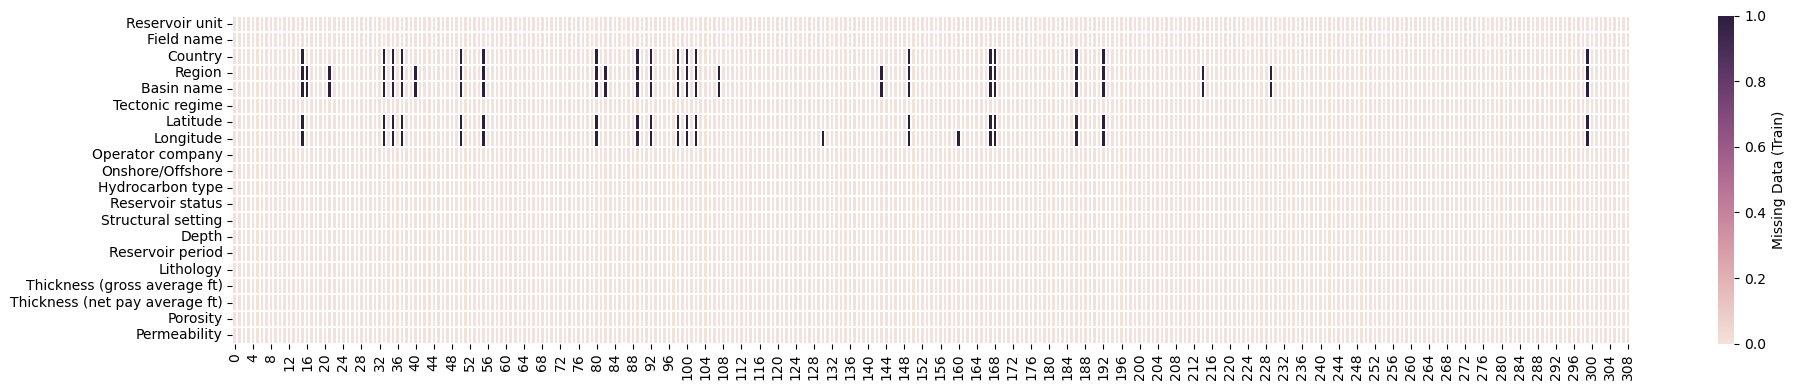

In [28]:
# для одной таблицы
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 4))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.003)

plt.tight_layout()
plt.savefig("./classification-of-oil-and-gas/visualizing_missing_data_with_heatmap_Seaborn_Python_less.png", dpi=100)
plt.show()


In [29]:
train[train['Basin name'].notna() & train.isna().any(axis='columns')]

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.390,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
160,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,GINDI,INVERSION/COMPRESSION/EXTENSION,29.783,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0


In [33]:
visual_check, filled_train = check_column_for_fill(train, 'Basin name')

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head().index
display(visual_check.head())
# как заполнилось
filled_train.loc[indices]

np.int64(107)

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.39,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,GHADAMES,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,GHADAMES,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,COMPRESSION/EROSION/EXTENSION,31.39,9.18,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,GHADAMES,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


In [34]:
# Применяем изменения
train = filled_train

train.isna().sum().sum()

np.int64(107)

Видно, что кое-где есть страна, но некоторые другие поля не заполнены.

In [35]:
train[train['Country'].notna() & train.isna().any(axis='columns')]

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,NaN,BASSEIN (ZONE B),HEERA,INDIA,NaN,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,NaN,YATES,NORTH WARD-ESTES,USA,NaN,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,NaN,F2-F0,WEST TEBUK,RUSSIA,NaN,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,NaN,LOWER GANCHAIGOU,GASIKULE,CHINA,NaN,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,NaN,TEMBLOR,COALINGA,USA,NaN,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,GINDI,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,NaN,GRAYBURG,SOUTH COWDEN,USA,NaN,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,NaN,POKUR (PK1-6),URENGOY,RUSSIA,NaN,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [36]:
visual_check, filled_train = check_column_for_fill(train, 'Country')

filled_train.isna().sum().sum()

np.int64(90)

In [37]:
indices = train[train['Country'].notna() & train.isna().any(axis='columns')].index

In [38]:
filled_train.loc[indices]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,INDIA,CAMBAY,BASSEIN (ZONE B),HEERA,FAR EAST,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,AUSTRALIA,GIPPSLAND,HUTTON,GIDGEALPA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,USA,GULF OF MEXICO NORTHERN ONSHORE,YATES,NORTH WARD-ESTES,NORTH AMERICA,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,RUSSIA,SIBERIAN WESTERN,F2-F0,WEST TEBUK,FORMER SOVIET UNION,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,CHINA,BOHAI,LOWER GANCHAIGOU,GASIKULE,FAR EAST,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,USA,GULF OF MEXICO NORTHERN ONSHORE,TEMBLOR,COALINGA,NORTH AMERICA,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,EGYPT,GINDI,LOWER BAHARIYA,QARUN,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,31.3616,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,USA,GULF OF MEXICO NORTHERN ONSHORE,GRAYBURG,SOUTH COWDEN,NORTH AMERICA,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,RUSSIA,SIBERIAN WESTERN,POKUR (PK1-6),URENGOY,FORMER SOVIET UNION,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [40]:
visual_check

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
83,BONAPARTE,PLOVER,SUNRISE-TROUBADOUR,AUSTRALIA,FAR EAST,EXTENSION/TRANSTENSION,-9.5901,128.1538,WOODSIDE,OFFSHORE,GAS-CONDENSATE,UNDEVELOPED,WRENCH/PASSIVE MARGIN,6660,JURASSIC,SANDSTONE,591.0,279.0,14.0,28.0
110,GIPPSLAND,LATROBE (M1 UNIT),BARRACOUTA,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2786,147.7094,EXXONMOBIL /BHP BILLITON,OFFSHORE,OIL,TEMPORARILY SHUT-IN,INVERSION/RIFT,4360,PALEOGENE,SANDSTONE,98.0,49.0,27.0,5000.0
150,OTWAY,PRETTY HILL (SANDSTONE),KATNOOK,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-37.4556,140.7789,BORAL ENERGY RESOURCES LTD,ONSHORE,GAS,PLATEAU PRODUCTION,RIFT,9286,CRETACEOUS,SANDSTONE,221.0,62.0,14.5,8.6
209,GIPPSLAND,LATROBE (N-1 UNIT),SNAPPER,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2008,148.0136,EXXONMOBIL /BHP BILLITON,OFFSHORE,GAS-CONDENSATE,PLATEAU PRODUCTION,INVERSION/RIFT,3682,PALEOGENE,SANDSTONE,820.0,394.0,24.0,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,WILLISTON,SPEARFISH,WESTHOPE SOUTH,USA,NORTH AMERICA,COMPRESSION,48.8521,-101.0130,AMERADA HESS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,3275,TRIASSIC,SANDSTONE,43.0,15.5,14.0,13.5
303,PERMIAN,SAN ANDRES,EMMA,USA,NORTH AMERICA,COMPRESSION,32.1270,-102.6353,EXXONMOBIL,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4185,PERMIAN,DOLOMITE,350.0,40.0,8.0,3.0
306,UINTA,GREEN RIVER AND COLTON/WASATCH,ALTAMONT-BLUEBELL,USA,NORTH AMERICA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,POWDER RIVER,MUDDY,BELL CREEK,USA,NORTH AMERICA,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [41]:
train = filled_train

In [43]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       18
Basin name    18
Region        18
Latitude      18
Longitude     18
dtype: int64

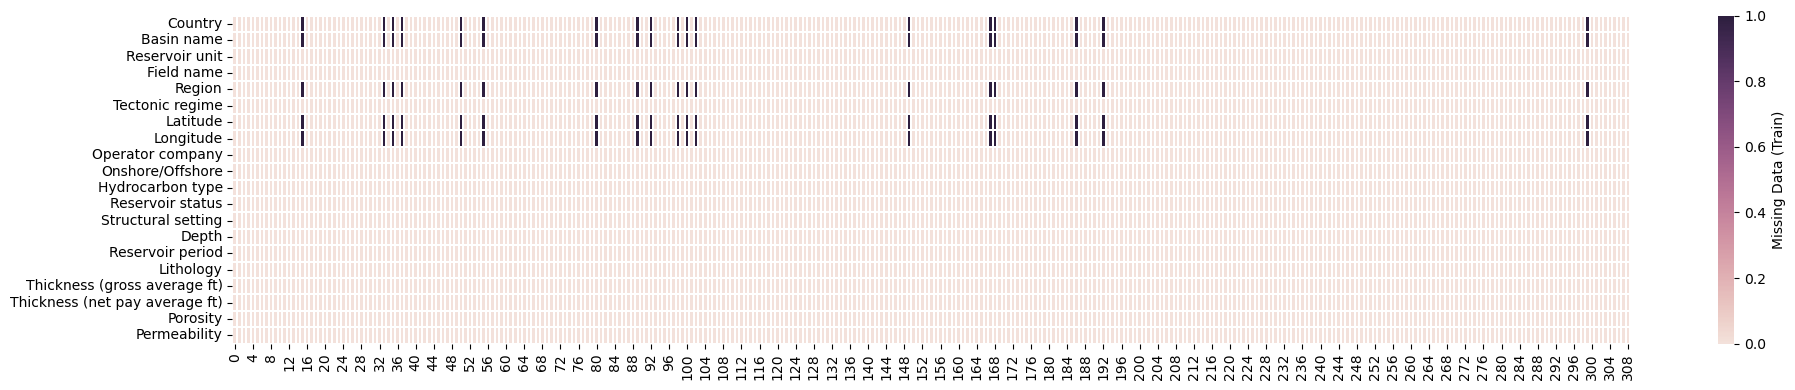

In [44]:
# для одной таблицы
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 4))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.003)

plt.tight_layout()
plt.savefig("./classification-of-oil-and-gas/visualizing_missing_data_with_heatmap_Seaborn_Python_less.png", dpi=100)
plt.show()


In [56]:
indices_all = train[train.isna().any(axis='columns')].index
train[train.isna().any(axis='columns')]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,NEXEN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
33,NaN,NaN,UPPER GANCHAIGOU-LOWER YOUSHAS,GASIKULE,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,4199,NEOGENE,SANDSTONE,3281.0,81.0,19.0,102.00
35,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,MANGYSTAUMUNAIGAZ,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
37,NaN,NaN,ULA,ULA,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,NaN,NaN,BP,OFFSHORE,OIL,MATURE PRODUCTION,SALT/INVERSION/RIFT,10744,JURASSIC,SANDSTONE,410.0,377.0,16.5,300.00
50,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,MAGELLAN PETROLEUM,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
55,NaN,NaN,HUANGLONG,WUBAITI,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,GAS,DEVELOPING,THRUST,13780,CARBONIFEROUS,DOLOMITE,98.0,79.0,6.0,0.77
80,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ANSCHUTZ AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
89,NaN,NaN,TURNER VALLEY (RUNDLE C POOL),HARMATTAN-ELKTON,NaN,COMPRESSION/EROSION,NaN,NaN,BP AND OTHERS,ONSHORE,GAS-CONDENSATE,MATURE PRODUCTION,FORELAND,8750,CARBONIFEROUS,DOLOMITE,140.0,70.0,12.0,125.00
92,NaN,NaN,LA ROSA-LAGUNILLAS (TIA JUANA ONSHORE AREA),TIA JUANA,NaN,COMPRESSION/EROSION,NaN,NaN,PDVSA,ONSHORE-OFFSHORE,OIL,MATURE PRODUCTION,WRENCH/FORELAND,1400,NEOGENE,SANDSTONE,500.0,120.0,35.0,1200.00
98,NaN,NaN,ABO,EMPIRE ABO,NaN,COMPRESSION,NaN,NaN,BP,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,5600,PERMIAN,DOLOMITE,300.0,151.0,10.0,50.00


In [57]:
visual_check, filled_train = check_column_for_fill(train, 'Operator company')

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(40)

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,PETROCHINA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,PETROCHINA,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,PETROCHINA,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,NaN,NaN,CLEARFORK-GLORIETA,NORTH ROBERTSON,NaN,COMPRESSION,NaN,NaN,TOTAL,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,TOTAL,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,PETROCHINA,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,PETROCHINA,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,TOTAL,UK,NORTH SEA NORTHERN,CLEARFORK-GLORIETA,NORTH ROBERTSON,EUROPE,COMPRESSION,60.7833,1.7333,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,TOTAL,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


In [58]:
train = filled_train

In [59]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       8
Basin name    8
Region        8
Latitude      8
Longitude     8
dtype: int64

In [62]:
visual_check, filled_train = check_column_for_fill(train, 'Structural setting')

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(0)

,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,THRUST,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,THRUST,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,THRUST,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
206,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI L SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,NEARLY DEPLETED,1362,PALEOGENE,SANDSTONE,180.0,39.0,23.0,619.0
216,THRUST,PETROCHINA,CHINA,JIUQUAN,BAIYANGHE (JIANQUANZI M SAND),LAOJUNMIAO,FAR EAST,COMPRESSION/EROSION/EXTENSION/LINKED,39.7658,97.5663,ONSHORE,OIL,MATURE PRODUCTION,1532,PALEOGENE,SANDSTONE,210.0,82.0,17.8,24.0
224,THRUST,CHEVRON,USA,ANADARKO,HUNTON (CHIMNEY HILL-HENRYHOUSE),MILLS RANCH,NORTH AMERICA,COMPRESSION/EROSION,35.3676,-100.0793,ONSHORE,GAS,NEARLY DEPLETED,19888,SILURIAN,DOLOMITE,930.0,94.0,6.0,7.0
277,THRUST,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.0
304,THRUST,OIL SEARCH LTD,PAPUA NEW GUINEA,PAPUAN FTB,IMBURU-TORO,HIDES,FAR EAST,COMPRESSION,-6.0136,142.8409,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0


In [63]:
train = filled_train